In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/NUS/Classes/CS5242/project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NUS/Classes/CS5242/project


In [2]:
import pandas as pd
from collections import Counter
from src.data_processing.data_processing import load_mini_imagenet, explore_dataset
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
DATA_PATH = "data/"
SAVE_DIR='experiments/data_analysis/'

In [4]:
save_dir = Path(SAVE_DIR)

In [5]:
ds = load_mini_imagenet(subset=None, cache_path=DATA_PATH)

In [6]:
for split in ds:
    print(split, len(ds[split]))

train 50000
validation 10000
test 5000


In [7]:
ds['train'].features

{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['n01532829', 'n01558993', 'n01704323', 'n01749939', 'n01770081', 'n01843383', 'n01855672', 'n01910747', 'n01930112', 'n01981276', 'n02074367', 'n02089867', 'n02091244', 'n02091831', 'n02099601', 'n02101006', 'n02105505', 'n02108089', 'n02108551', 'n02108915', 'n02110063', 'n02110341', 'n02111277', 'n02113712', 'n02114548', 'n02116738', 'n02120079', 'n02129165', 'n02138441', 'n02165456', 'n02174001', 'n02219486', 'n02443484', 'n02457408', 'n02606052', 'n02687172', 'n02747177', 'n02795169', 'n02823428', 'n02871525', 'n02950826', 'n02966193', 'n02971356', 'n02981792', 'n03017168', 'n03047690', 'n03062245', 'n03075370', 'n03127925', 'n03146219', 'n03207743', 'n03220513', 'n03272010', 'n03337140', 'n03347037', 'n03400231', 'n03417042', 'n03476684', 'n03527444', 'n03535780', 'n03544143', 'n03584254', 'n03676483', 'n03770439', 'n03773504', 'n03775546', 'n03838899', 'n03854065', 'n03888605', 'n03908618', 'n03924679', 'n039808

In [8]:
class_names = ds['train'].features['label'].names
print(len(class_names))

100


In [9]:
# class distribution
labels = ds['train']['label']
counts = Counter(labels)

df = pd.DataFrame.from_dict(counts, orient='index', columns=['count'])
df = df.sort_index()

print(df)

    count
0     500
1     500
2     500
3     500
4     500
..    ...
95    500
96    500
97    500
98    500
99    500

[100 rows x 1 columns]


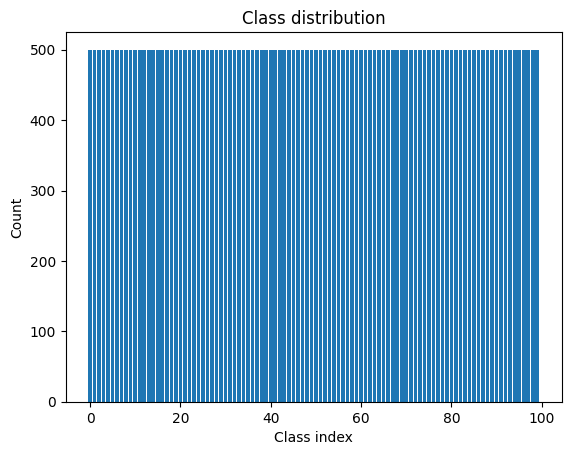

In [10]:
plt.bar(df.index, df['count'])
plt.title("Class distribution")
plt.xlabel("Class index")
plt.ylabel("Count")
plt.show()

In [11]:
# image analysis
sizes = []

for example in ds['train']:
    sizes.append(example['image'].size)

size_df = pd.DataFrame(sizes, columns=["width","height"])

print(size_df.describe())

              width        height
count  50000.000000  50000.000000
mean     469.688200    407.340640
std      219.199056    190.793053
min       14.000000     32.000000
25%      375.000000    333.000000
50%      500.000000    375.000000
75%      500.000000    500.000000
max     4768.000000   5980.000000


In [12]:
size_df

,width,height
0,357,500
1,500,480
2,500,361
3,500,312
4,500,333
...,...,...
49995,300,400
49996,523,800
49997,500,375
49998,422,317


In [13]:
size_df.value_counts()

width  height
500    375       11543
       333        4044
375    500        3303
333    500        1468
500    334        1029
                 ...  
48     40            1
46     130           1
35     260           1
34     159           1
14     130           1
Name: count, Length: 10093, dtype: int64

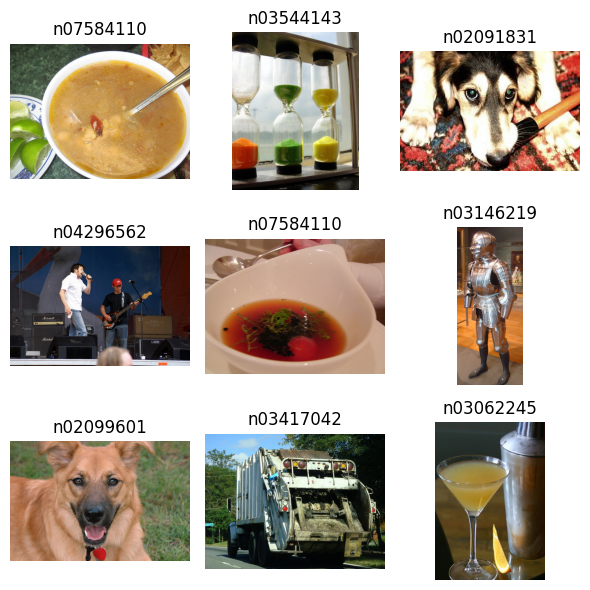

In [14]:
fig, axes = plt.subplots(3,3, figsize=(6,6))

for ax in axes.flatten():
    example = ds['train'].shuffle()[0]
    ax.imshow(example['image'])
    ax.set_title(class_names[example['label']])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# means = []
# stds = []

# for example in ds['train'].select(range(1000)):  # sample
#     img = np.array(example['image']) / 255.0 # normalize to [0,1]
#     means.append(img.mean(axis=(0,1)))
#     stds.append(img.std(axis=(0,1)))

# mean = np.mean(means, axis=0)
# std = np.mean(stds, axis=0)

# print("Mean:", mean)
# print("Std:", std)

In [16]:
# example['image']

In [17]:
np.array(example['image']).shape

(428, 296, 3)

In [18]:

explore_dataset(ds, save_dir)

Saved class distribution plot.
Number of classes: 100. Balanced? min=500 max=500 (ideally equal)


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Saved image metadata (resolutions/formats/modes).
Saved visual inspection grid to: experiments/data_analysis/visual_grid.png
Computed mean/std: mean=[0.4731537  0.4487519  0.40382388], std=[0.28395614 0.27580795 0.29069683]. Saved to train_mean_std.json
